RMSE on held-out test horizon
Seasonal Naive: 3,198,710.346
ETS:           6,480,404.661
ETS + XGB:     4,786,436.788


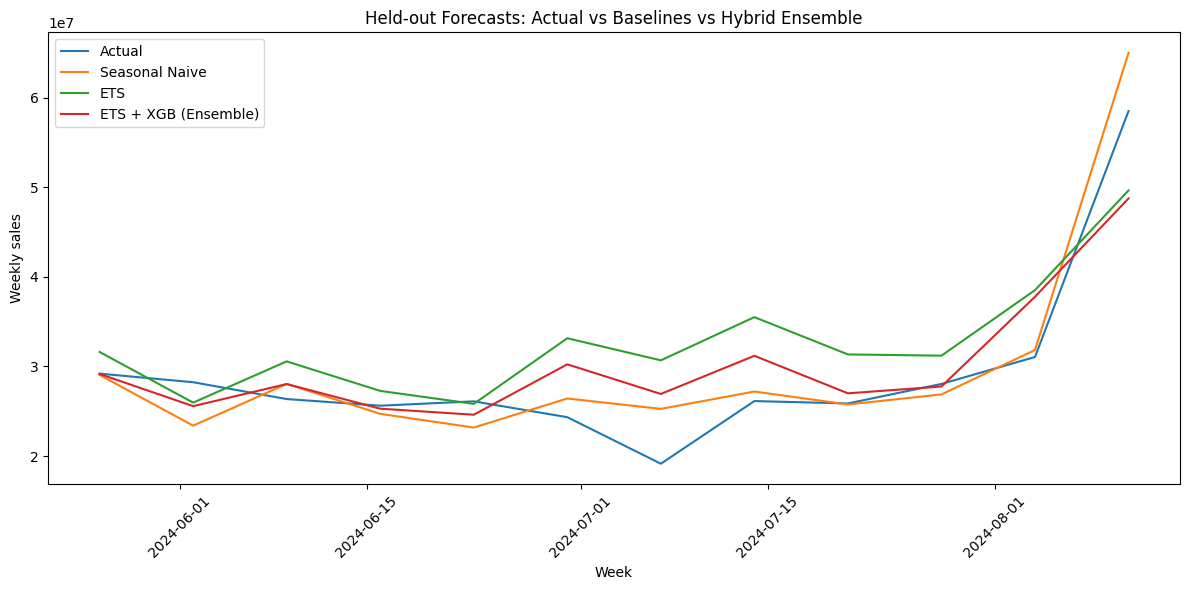

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

# --------------------------------------
# 1. Load and prepare data
# --------------------------------------

# Load cleaned data
df = pd.read_excel("Sample_data_cleaned.xlsx")

# Ensure datetime
df["date"] = pd.to_datetime(df["date"])

# --------------------------------------
# 2. Aggregate daily data to weekly
# --------------------------------------

# Weekly aggregation aligns with HQ planning horizon
df_weekly = (
    df
    .set_index("date")
    .resample("W")["sales"]
    .sum()
    .reset_index()
)

# --------------------------------------
# 3. Create a time-based train/test split
# --------------------------------------
# Choose a fixed forecast horizon for evaluation (for example, last 12 weeks)
TEST_WEEKS = 12

if len(df_weekly) <= TEST_WEEKS + 52:
    raise ValueError(
        "Not enough weekly data. Need at least ~1 year + test horizon to make seasonality meaningful."
    )

train_df = df_weekly.iloc[:-TEST_WEEKS].copy()
test_df  = df_weekly.iloc[-TEST_WEEKS:].copy()

# --------------------------------------
# 4. Baseline 1: Seasonal Naive (weekly, yearly seasonality)
# --------------------------------------
SEASONAL_PERIOD = 52  # weekly data, yearly seasonality

if len(train_df) < SEASONAL_PERIOD:
    raise ValueError("Training window must be at least 52 weeks for seasonal naive.")

# Predict test week t using value from t-52
seasonal_naive_pred = []
for i in range(len(test_df)):
    idx_in_full = len(train_df) + i
    # y_hat[t] = y[t-52]
    y_hat = df_weekly.loc[idx_in_full - SEASONAL_PERIOD, "sales"]
    seasonal_naive_pred.append(float(y_hat))

test_df["pred_seasonal_naive"] = seasonal_naive_pred

# --------------------------------------
# 5. Baseline 2: ETS (structural baseline)
# --------------------------------------
# Notes:
# - ETS captures level/trend/seasonality as an explicit, smooth structure
# - We fit on training only, then forecast into the test horizon

# Many retail series work with additive seasonality; if your series scales strongly
# with level, try seasonal="mul". Start with additive for interpretability.
ets_model = ExponentialSmoothing(
    train_df["sales"].astype(float),
    trend="add",
    seasonal="add",
    seasonal_periods=SEASONAL_PERIOD
)

ets_fit = ets_model.fit(optimized=True)
ets_forecast = ets_fit.forecast(len(test_df))

test_df["pred_ets"] = ets_forecast.values.astype(float)

# --------------------------------------
# 6. Hybrid model: ETS + XGBoost residual learner
# --------------------------------------
# Core idea from Section 7:
# 1) ETS provides stable global structure
# 2) XGBoost learns residual calendar interactions with only safe timestamp features
# 3) Final forecast = ETS forecast + predicted residual

from xgboost import XGBRegressor

def add_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Deliberately minimal, forecast-time-safe calendar features.
    Uses only date, no lags, no rolling statistics.
    """
    out = frame.copy()
    dt = out["date"]

    out["year"] = dt.dt.year.astype(int)
    out["month"] = dt.dt.month.astype(int)

    # Week of month: 1..5 (approx). This is a common simple proxy.
    out["week_of_month"] = ((dt.dt.day - 1) // 7 + 1).astype(int)

    return out

# 6.1 Build residuals on training only (no test leakage)
train_feat = add_calendar_features(train_df)
test_feat  = add_calendar_features(test_df)

# In-sample ETS fitted values for the training window
# Statsmodels returns fittedvalues aligned to training index length
train_df["ets_fitted"] = ets_fit.fittedvalues.values.astype(float)

# Residuals = actual - baseline
train_df["residual"] = (train_df["sales"].astype(float) - train_df["ets_fitted"]).astype(float)

# 6.2 Train residual model (XGBoost) on training residuals
FEATURE_COLS = ["year", "month", "week_of_month"]

X_train = train_feat[FEATURE_COLS].values
y_train = train_df["residual"].values

X_test = test_feat[FEATURE_COLS].values

# Conservative hyperparameters: shallow trees, low learning rate
xgb_resid = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    min_child_weight=5,
    objective="reg:squarederror",
    random_state=42
)

xgb_resid.fit(X_train, y_train)

# 6.3 Predict residuals for test horizon
test_df["pred_residual_xgb"] = xgb_resid.predict(X_test).astype(float)

# 6.4 Final ensemble forecast
test_df["pred_ensemble"] = (test_df["pred_ets"] + test_df["pred_residual_xgb"]).astype(float)

# --------------------------------------
# 7. Evaluation (RMSE) on the held-out horizon
# --------------------------------------
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

y_true = test_df["sales"].astype(float).values

rmse_seasonal_naive = rmse(y_true, test_df["pred_seasonal_naive"].values)
rmse_ets            = rmse(y_true, test_df["pred_ets"].values)
rmse_ensemble        = rmse(y_true, test_df["pred_ensemble"].values)

print("RMSE on held-out test horizon")
print(f"Seasonal Naive: {rmse_seasonal_naive:,.3f}")
print(f"ETS:           {rmse_ets:,.3f}")
print(f"ETS + XGB:     {rmse_ensemble:,.3f}")

# --------------------------------------
# 8. Plot forecasts vs actuals (test window)
# --------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(test_df["date"], test_df["sales"], label="Actual")
plt.plot(test_df["date"], test_df["pred_seasonal_naive"], label="Seasonal Naive")
plt.plot(test_df["date"], test_df["pred_ets"], label="ETS")
plt.plot(test_df["date"], test_df["pred_ensemble"], label="ETS + XGB (Ensemble)")
plt.title("Held-out Forecasts: Actual vs Baselines vs Hybrid Ensemble")
plt.xlabel("Week")
plt.ylabel("Weekly sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.legend()
plt.show()

# --------------------------------------
# 9. Optional: Quantile residual intervals (uncertainty)
# --------------------------------------
# This produces an uncertainty band without adding exogenous features.
# It trains two additional models on residuals for lower and upper quantiles.

ENABLE_QUANTILES = False

if ENABLE_QUANTILES:
    # Pinball loss objectives: quantile regression
    # XGBoost supports quantile with "reg:quantileerror" in newer versions.
    # If your xgboost does not support it, skip this block.
    lower_q = 0.05
    upper_q = 0.95

    xgb_low = XGBRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=5,
        objective="reg:quantileerror",
        quantile_alpha=lower_q,
        random_state=42
    )

    xgb_high = XGBRegressor(
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        min_child_weight=5,
        objective="reg:quantileerror",
        quantile_alpha=upper_q,
        random_state=42
    )

    xgb_low.fit(X_train, y_train)
    xgb_high.fit(X_train, y_train)

    test_df["resid_low"] = xgb_low.predict(X_test).astype(float)
    test_df["resid_high"] = xgb_high.predict(X_test).astype(float)

    test_df["pred_lower"] = test_df["pred_ets"] + test_df["resid_low"]
    test_df["pred_upper"] = test_df["pred_ets"] + test_df["resid_high"]

    plt.figure(figsize=(12, 6))
    plt.plot(test_df["date"], test_df["sales"], label="Actual")
    plt.plot(test_df["date"], test_df["pred_ensemble"], label="Ensemble mean")
    plt.fill_between(
        test_df["date"],
        test_df["pred_lower"],
        test_df["pred_upper"],
        alpha=0.2,
        label="Ensemble 90% interval (residual quantiles)"
    )
    plt.title("Ensemble Forecast with Residual Quantile Interval")
    plt.xlabel("Week")
    plt.ylabel("Weekly sales")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()


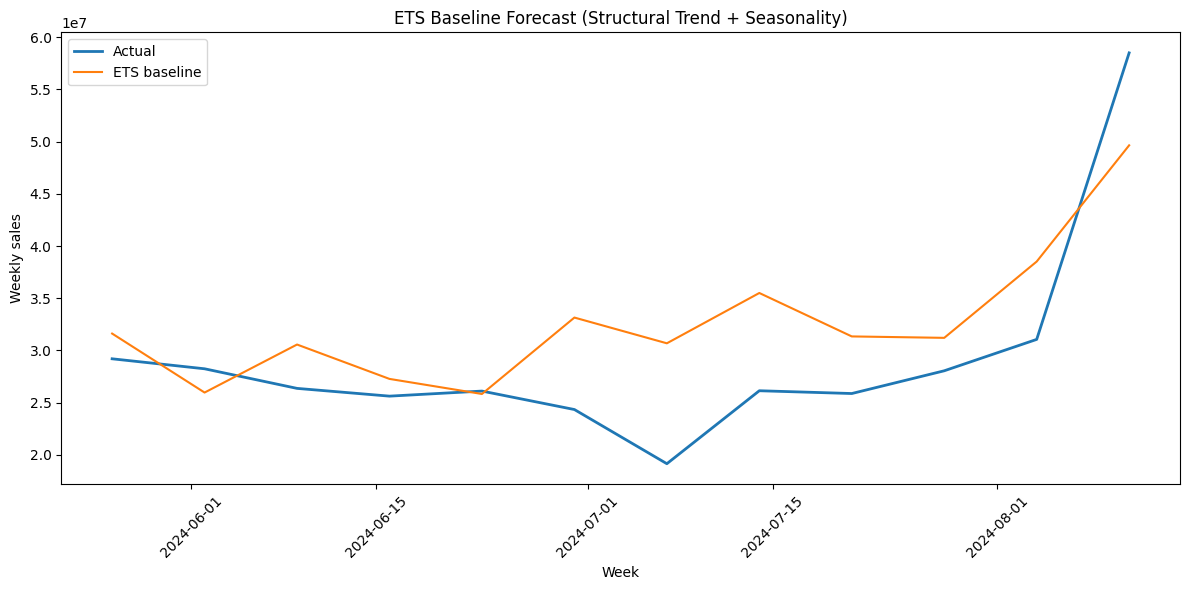

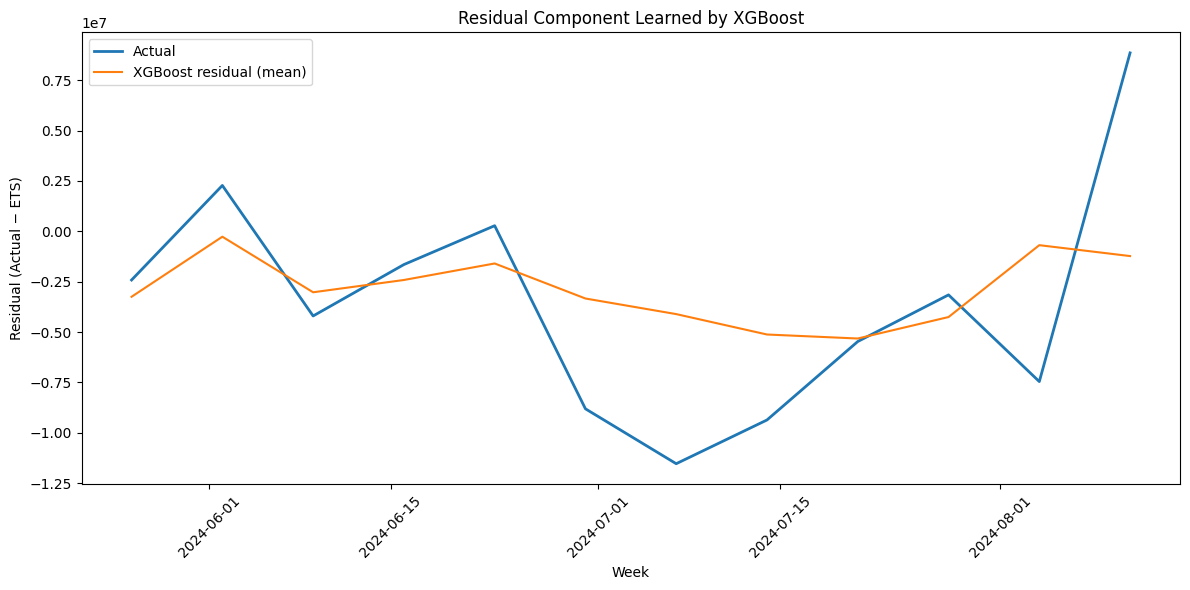

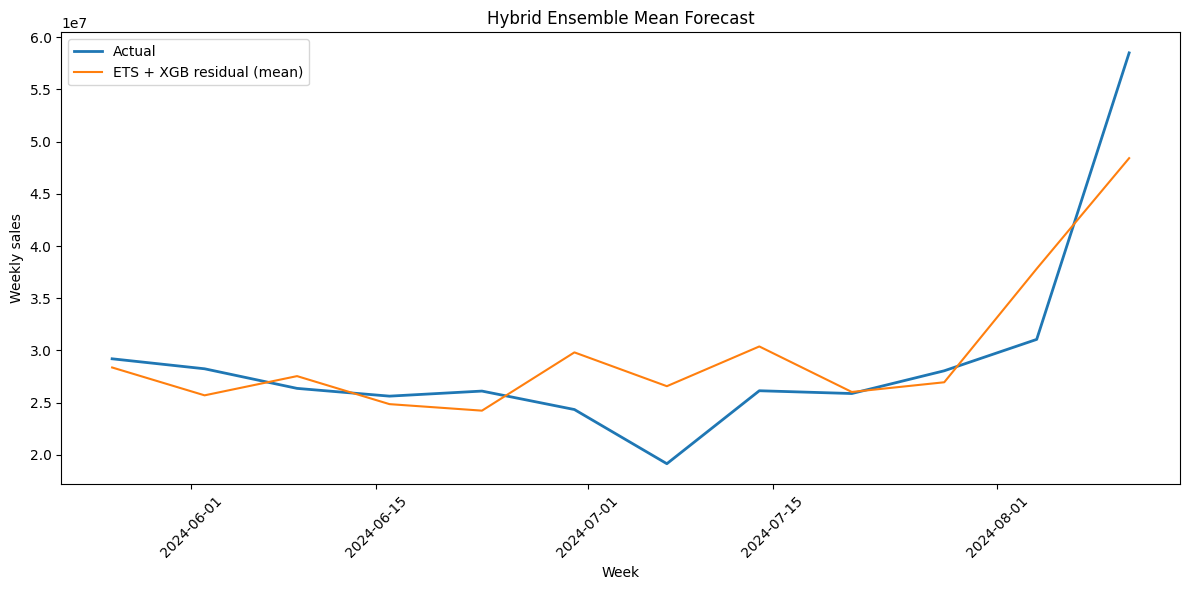

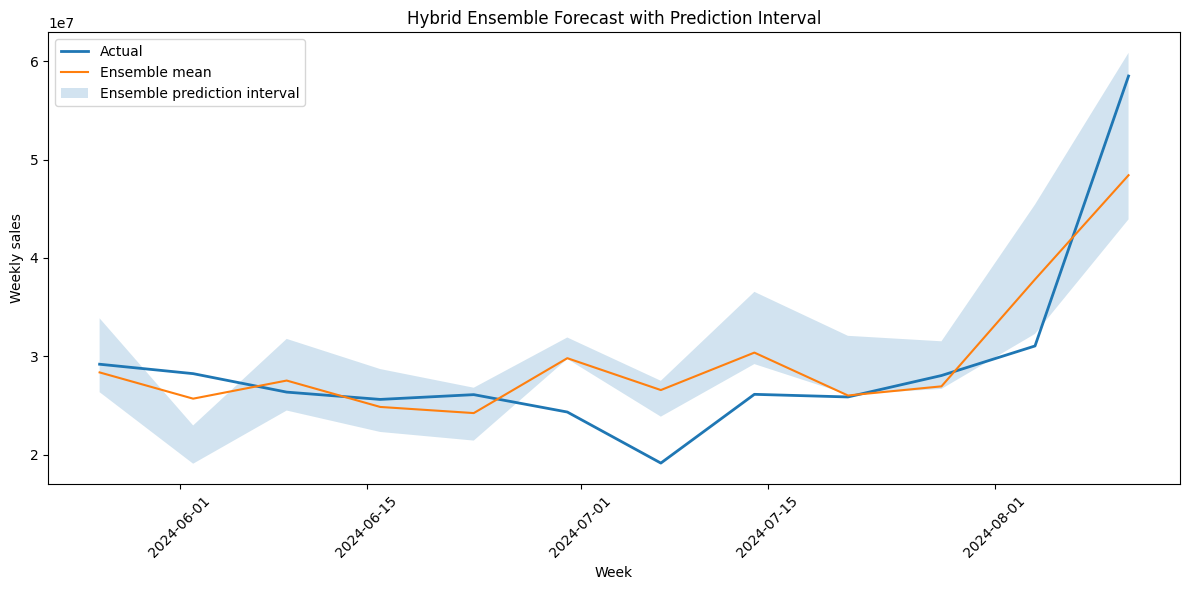

In [4]:
# --------------------------------------
# 6B-7. Diagnostic plots for each model component
# --------------------------------------

# Common plot helper
def plot_series(
    dates,
    actual,
    preds,
    title,
    ylabel="Weekly sales",
    interval=None
):
    plt.figure(figsize=(12, 6))
    plt.plot(dates, actual, label="Actual", linewidth=2)

    for name, values in preds.items():
        plt.plot(dates, values, label=name)

    if interval is not None:
        lower, upper, label = interval
        plt.fill_between(
            dates,
            lower,
            upper,
            alpha=0.2,
            label=label
        )

    plt.title(title)
    plt.xlabel("Week")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


# --------------------------------------
# Plot 1: ETS baseline only (structural anchor)
# --------------------------------------
plot_series(
    dates=test_df["date"],
    actual=test_df["sales"],
    preds={
        "ETS baseline": test_df["pred_ets"]
    },
    title="ETS Baseline Forecast (Structural Trend + Seasonality)"
)


# --------------------------------------
# Plot 2: Residuals learned by XGBoost
# --------------------------------------
plot_series(
    dates=test_df["date"],
    actual=test_df["sales"] - test_df["pred_ets"],
    preds={
        "XGBoost residual (mean)": test_df["pred_residual_mean"]
    },
    title="Residual Component Learned by XGBoost",
    ylabel="Residual (Actual − ETS)"
)


# --------------------------------------
# Plot 3: Ensemble mean forecast
# --------------------------------------
plot_series(
    dates=test_df["date"],
    actual=test_df["sales"],
    preds={
        "ETS + XGB residual (mean)": test_df["pred_ensemble_mean"]
    },
    title="Hybrid Ensemble Mean Forecast"
)


# --------------------------------------
# Plot 4: Ensemble forecast with interval (decision-support view)
# --------------------------------------
plot_series(
    dates=test_df["date"],
    actual=test_df["sales"],
    preds={
        "Ensemble mean": test_df["pred_ensemble_mean"]
    },
    interval=(
        test_df["pred_ensemble_low"],
        test_df["pred_ensemble_high"],
        "Ensemble prediction interval"
    ),
    title="Hybrid Ensemble Forecast with Prediction Interval"
)
